# Inferência — identidades coloridas e contagem de objetos únicos

Entregável do PA2. Recebe o caminho de **uma sequência qualquer** no formato MOTChallenge e
devolve o vídeo com as identidades coloridas de forma consistente, mais a contagem de
objetos únicos.

**Roda sem retreinar**: carrega os pesos de `outputs/p2/best.pth` e só faz inferência.

Funciona nas sequências sintéticas da Parte 0 e nas do MOT17 pelo mesmo caminho — o gerador
da Parte 0 grava em formato MOTChallenge de propósito, e é isso que faz o resto do projeto
não precisar distinguir as duas fontes.

In [1]:
import sys
from pathlib import Path

# a raiz do projeto no sys.path, para o notebook rodar de dentro de notebooks/
RAIZ = Path.cwd()
if not (RAIZ / "main.py").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np

from src.inference.predict import (
    carregar_modelo, carregar_sequencia, cor_da_identidade, desenhar,
    gravar_video, rastrear,
)
print("raiz do projeto:", RAIZ)

raiz do projeto: /home/jotinha/Documentos/Github/deep-learning/object-detection-in-videos


## 1. O que rastrear e com que pesos

Troque `SEQUENCIA` para apontar para qualquer pasta com `det/det.txt`, `seqinfo.ini` e
`img1/`. As opções que existem neste repositório:

| caminho | o que é | precisa do download grande? |
|---|---|---|
| `outputs/p0/sequences/SYNTH-VAL-00` | sintético da Parte 0 | não |
| `src/data/datasets/MOT17/train/MOT17-10-SDP` | **validação** — o padrão | sim (imagens) |
| `src/data/datasets/MOT17/train/MOT17-09-SDP` | teste, parada e esparsa | sim |
| `src/data/datasets/MOT17/train/MOT17-05-SDP` | teste, 640x480 a 14 fps — fora da distribuição | sim |

O padrão é a **validação**, de propósito: este notebook é rodado muitas vezes durante o
desenvolvimento, e cada execução numa sequência de teste é uma olhada no conjunto que
deveria ser tocado uma vez só. Para a demonstração final, troque para uma das duas de teste —
são as que o modelo nunca viu, e é nelas que o número significa alguma coisa.

In [2]:
SEQUENCIA  = RAIZ / "src/data/datasets/MOT17/train/MOT17-10-SDP"
CONFIG     = RAIZ / "configs/mot17_gru.yaml"
CHECKPOINT = RAIZ / "outputs/p2/best.pth"
SAIDA      = RAIZ / "outputs/inferencia"

model, cfg = carregar_modelo(CONFIG, CHECKPOINT)
botoes = {k: v for k, v in cfg.get_eval_config().tracking.items() if k != "tracker"}

print(f"modelo: {model.config()}")
print(f"parâmetros: {model.n_parametros():,}")
print(f"associação e gestão de tracks: {botoes}")

modelo: {'cell': 'gru', 'hidden': 55, 'layers': 1, 'prever_incerteza': False}
parâmetros: 19,364
associação e gestão de tracks: {'iou_threshold': 0.3, 'max_age': 10, 'min_hits': 3, 'associacao': 'hungarian', 'emitir_sem_observacao': False}


## 2. Rastrear

Um estado recorrente por track. A cada quadro: a recorrência prevê onde cada track deve
estar, o Hungarian casa as previsões com as detecções, quem casou absorve a observação e
quem não casou **continua andando com a própria previsão** — que é a única diferença real
em relação ao baseline por IoU.

In [3]:
resultado = rastrear(SEQUENCIA, model, botoes)

print(f"sequência:            {resultado['nome']}")
print(f"quadros:              {len(resultado['predicao'])}")
print(f"detecções na entrada: {resultado['n_deteccoes']:,}")
print()
print(f"OBJETOS ÚNICOS NO VÍDEO: {resultado['n_identidades']}")

if resultado["gabarito"] is not None:
    verdadeiras = len(resultado["gabarito"].track_ids)
    erro = abs(resultado["n_identidades"] - verdadeiras)
    print(f"  identidades verdadeiras: {verdadeiras}")
    print(f"  erro de contagem:        {erro}  ({resultado['n_identidades'] / verdadeiras:.1f}x)")

sequência:            MOT17-10-SDP
quadros:              654
detecções na entrada: 10,371

OBJETOS ÚNICOS NO VÍDEO: 224
  identidades verdadeiras: 57
  erro de contagem:        167  (3.9x)


## 3. As métricas, se a pasta tiver gabarito

Um vídeo novo não tem `gt.txt`, e o rastreamento acima funciona sem ele. Quando existe, dá
para medir — com a nossa implementação de IDF1, ID switches e fragmentações (`metrics.py`).

In [4]:
from metrics import evaluate

if resultado["gabarito"] is not None:
    m = evaluate(resultado["gabarito"], resultado["predicao"])
    print(f"  IDF1            {m.idf1:.4f}   (IDP {m.idp:.3f} · IDR {m.idr:.3f})")
    print(f"  ID switches     {m.id_switches}")
    print(f"  fragmentações   {m.fragmentations}")
    print(f"  erro de contagem {m.count_error}")
    print(f"  MOTA            {m.mota:.4f}")
else:
    print("pasta sem gt/gt.txt — nada a medir, só a saída do rastreador.")

  IDF1            0.4874   (IDP 0.548 · IDR 0.439)
  ID switches     395
  fragmentações   436
  erro de contagem 167
  MOTA            0.6560


## 4. Olhar alguns quadros

A cor é a identidade. O que se quer ver é a **mesma cor no mesmo objeto** ao longo dos
quadros — inclusive depois de ele sumir atrás de alguma coisa e voltar.

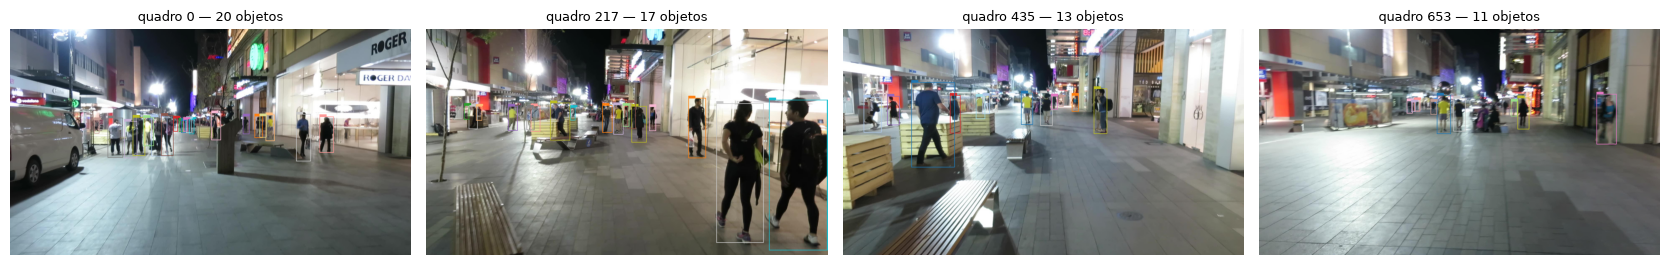

In [5]:
import imageio.v2 as imageio

info = resultado["info"]
predicao = resultado["predicao"]
quadros = np.linspace(0, len(predicao) - 1, num=4, dtype=int)

fig, eixos = plt.subplots(1, len(quadros), figsize=(4.2 * len(quadros), 3.2))
for ax, t in zip(np.atleast_1d(eixos), quadros):
    caminho = resultado["pasta"] / info["im_dir"] / f"{t + 1:06d}{info['im_ext']}"
    if caminho.exists():
        ax.imshow(desenhar(imageio.imread(caminho), predicao[t]))
    else:
        ax.text(0.5, 0.5, "imagem não baixada\n(make dados-imagens)",
                ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"quadro {t} — {len(predicao[t])} objetos", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. O vídeo

Grava o mp4 com as caixas coloridas por identidade. É o entregável que o enunciado pede:
*"recebe o caminho de uma sequência qualquer, devolve o vídeo com as identidades coloridas
de forma consistente e a contagem de objetos únicos. Roda sem retreinar."*

In [6]:
destino = gravar_video(resultado, SAIDA / f"{resultado['nome']}_identidades.mp4")
print(f"vídeo: {destino}")
print(f"{len(resultado['predicao'])} quadros a {info['fps']:g} fps, "
      f"{resultado['n_identidades']} identidades")

vídeo: /home/jotinha/Documentos/Github/deep-learning/object-detection-in-videos/outputs/inferencia/MOT17-10-SDP_identidades.mp4
654 quadros a 30 fps, 224 identidades


## 6. Quanto tempo cada identidade dura

Um diagnóstico barato e que diz muito: uma nuvem de tracks curtas significa que o
rastreador está partindo objetos, e é exatamente o que o erro de contagem de identidades
únicas mede.

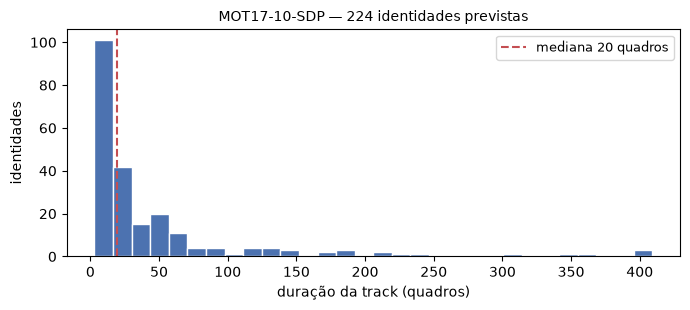

33 de 224 tracks duram 5 quadros ou menos (15%)


In [7]:
duracoes = [
    sum(1 for f in predicao if track_id in set(f.ids.tolist()))
    for track_id in predicao.track_ids
]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(duracoes, bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(np.median(duracoes), color="#C44E52", ls="--",
           label=f"mediana {np.median(duracoes):.0f} quadros")
ax.set_xlabel("duração da track (quadros)")
ax.set_ylabel("identidades")
ax.set_title(f"{resultado['nome']} — {len(duracoes)} identidades previstas", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

curtas = sum(1 for d in duracoes if d <= 5)
print(f"{curtas} de {len(duracoes)} tracks duram 5 quadros ou menos "
      f"({100 * curtas / len(duracoes):.0f}%)")